# task3：Version8 强蒸馏版光电混合 D2NN

这版 notebook 的目标不是继续沿用 Version7 的 `24x32 token -> teacher cls` 老路线，
而是回到更符合光电物理结构的主线：

- 学生主干明确写成 `相位板 -> 传播 -> CMOS -> 重构 -> 下一层`
- 每层监督点放在 CMOS 读出的 `14x14` 压缩 map 上
- 默认只保留简单电操作：`sqrt`
- 第一阶段先做固定 teacher target 的强蒸馏
- 第二阶段只在后几层引入链式 teacher target
- 第三阶段只做低学习率稳定微调，可按需关闭

当前已知参考：

- 灰度 CIFAR-10 的 D2NN baseline 约为 `57%`
- Version8 目标是先把强 KD 主线写清楚、跑通、便于调试


## 0) 导入依赖 + 全局基础配置

风格尽量保持和 Version7 / baseline 一致：

- 参数集中放在靠前位置，便于改实验
- 每个大阶段独立 markdown + 配置 cell + 执行 cell
- 工具函数尽量集中，避免 notebook 后面东一块西一块
- 中文注释保留，但避免花里胡哨字符，降低乱码风险


In [1]:
import os
import json
import math
import time
import random
from copy import deepcopy
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision.transforms import functional as TF
from torchvision.models import vit_b_16, ViT_B_16_Weights

from tqdm.auto import tqdm


plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

SEED = 42
NUM_CLASSES = 10
CLASSES = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

DATA_DIR = Path("./data")
OUT_DIR = Path("./results_task3_kd_v8_strong_optical")
CKPT_DIR = OUT_DIR / "checkpoints"
LOG_DIR = OUT_DIR / "logs"
FIG_DIR = OUT_DIR / "figures"
for p in [OUT_DIR, CKPT_DIR, LOG_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", DEVICE)
print("OUT_DIR =", OUT_DIR.resolve())

GRAY_D2NN_BASELINE_REF_ACC = 0.57

STUDENT_IMG_SIZE = 128
TEACHER_IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2
ALIGN_POOL_SIZE = 14

D2NN_NUM_LAYERS = 12
D2NN_CHANNELS = 1
D2NN_WAVELENGTH = 532e-9
D2NN_PIXEL_SIZE = 8e-6
D2NN_PROP_DISTANCE = 0.01

INPUT_EPS = 1e-8
CMOS_EPS = 1e-8


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def save_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=2, ensure_ascii=False), encoding="utf-8")


def format_seconds(seconds: float) -> str:
    seconds = max(float(seconds), 0.0)
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = int(seconds % 60)
    if h > 0:
        return f"{h:d}h {m:02d}m {s:02d}s"
    return f"{m:02d}m {s:02d}s"


def set_trainable(module: nn.Module, flag: bool):
    if module is None:
        return
    for p in module.parameters():
        p.requires_grad = flag


def count_trainable_parameters(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters() if p.requires_grad)


def flexible_load_state_dict(model: nn.Module, ckpt_path: Path, strict: bool = False):
    payload = torch.load(ckpt_path, map_location="cpu")
    if isinstance(payload, dict):
        state = payload.get("model_state_dict", payload.get("state_dict", payload))
    else:
        state = payload
    missing, unexpected = model.load_state_dict(state, strict=strict)
    print(f"已加载 checkpoint: {ckpt_path}")
    if len(missing) > 0:
        print("missing keys 数量 =", len(missing))
    if len(unexpected) > 0:
        print("unexpected keys 数量 =", len(unexpected))
    return payload


set_seed(SEED)
print("ok: 0) 导入依赖 + 全局基础配置")


/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE = cuda
OUT_DIR = /D2NN_practices/results_task3_kd_v8_strong_optical
ok: 0) 导入依赖 + 全局基础配置


## 1) 灰度 CIFAR-10 双视角数据

这里仍然保留双视角：

- `x_student` 给 D2NN 学生，单通道灰度，尺寸 `128`
- `x_teacher` 给 ViT 教师，灰度复制成三通道，再走 ImageNet 风格归一化，尺寸 `224`

这样做的好处是：

- 学生保持光学输入逻辑
- 老师仍然能直接复用 ViT-B/16 的成熟实现
- 后续蒸馏阶段不需要再反复改数据管线


train size = 50000 | test size = 10000
train batches = 782 | test batches = 157
gray baseline reference = 57.00%


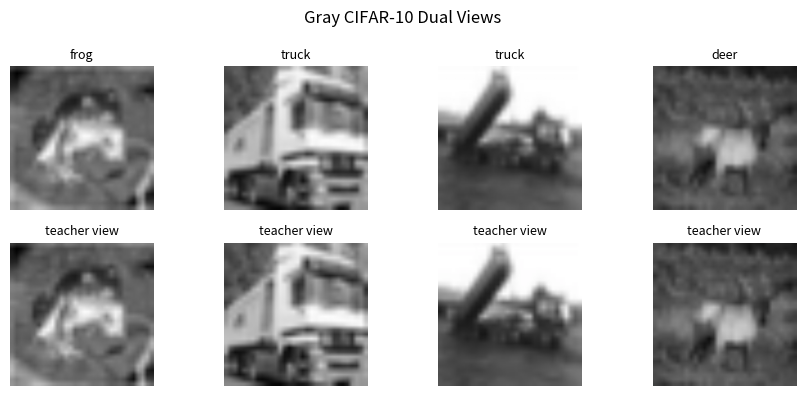

ok: 1) 灰度 CIFAR-10 双视角数据


In [2]:
class CIFAR10GrayDualView(Dataset):
    def __init__(self, root, train: bool = True, download: bool = True, student_img_size: int = STUDENT_IMG_SIZE, teacher_img_size: int = TEACHER_IMG_SIZE):
        self.base = datasets.CIFAR10(root=root, train=train, download=download, transform=None)
        self.train = train
        self.student_img_size = student_img_size
        self.teacher_img_size = teacher_img_size
        self.teacher_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.teacher_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.base)

    def _to_gray_tensor(self, pil_img, size: int):
        img = TF.resize(pil_img, [size, size])
        img = TF.to_grayscale(img, num_output_channels=1)
        x = TF.to_tensor(img)
        return x

    def _to_teacher_tensor(self, pil_img, size: int):
        gray = self._to_gray_tensor(pil_img, size)
        rgb = gray.repeat(3, 1, 1)
        rgb = (rgb - self.teacher_mean) / self.teacher_std
        return rgb

    def __getitem__(self, idx):
        img, label = self.base[idx]
        if self.train and random.random() < 0.5:
            img = TF.hflip(img)
        x_student = self._to_gray_tensor(img, self.student_img_size)
        x_teacher = self._to_teacher_tensor(img, self.teacher_img_size)
        return x_student, x_teacher, label


train_ds = CIFAR10GrayDualView(root=DATA_DIR, train=True, download=True, student_img_size=STUDENT_IMG_SIZE, teacher_img_size=TEACHER_IMG_SIZE)
test_ds = CIFAR10GrayDualView(root=DATA_DIR, train=False, download=True, student_img_size=STUDENT_IMG_SIZE, teacher_img_size=TEACHER_IMG_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


def show_gray_dual_samples(dataset, classes, n: int = 6):
    n = min(n, len(dataset))
    plt.figure(figsize=(2.2 * n, 4.0))
    for i in range(n):
        x_student, x_teacher, y = dataset[i]
        plt.subplot(2, n, i + 1)
        plt.imshow(x_student.squeeze(0), cmap="gray", vmin=0.0, vmax=1.0)
        plt.title(classes[y], fontsize=9)
        plt.axis("off")

        plt.subplot(2, n, i + 1 + n)
        teacher_vis = x_teacher.permute(1, 2, 0).cpu()
        teacher_vis = teacher_vis * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
        teacher_vis = teacher_vis.clamp(0, 1)
        plt.imshow(teacher_vis)
        plt.title("teacher view", fontsize=9)
        plt.axis("off")
    plt.suptitle("Gray CIFAR-10 Dual Views")
    plt.tight_layout()
    plt.show()


print("train size =", len(train_ds), "| test size =", len(test_ds))
print("train batches =", len(train_loader), "| test batches =", len(test_loader))
print("gray baseline reference =", f"{GRAY_D2NN_BASELINE_REF_ACC * 100:.2f}%")
show_gray_dual_samples(train_ds, CLASSES, n=4)
print("ok: 1) 灰度 CIFAR-10 双视角数据")


## 2) ViT-Base 教师模型

Version8 的关键变化之一，是不再让 student 去硬对齐 ViT 的原始 signed feature。

这里教师侧会额外提供两类输出：

- `logits`
- 每个 block 的 `patch tokens`

然后通过 teacher-side 压缩，把 `196 x 768` 的 patch token 压成 `14x14` 非负 target map。


In [3]:
class GrayViTTeacherV8(nn.Module):
    expects_teacher_input = True

    def __init__(self, num_classes: int = NUM_CLASSES, pretrained: bool = True):
        super().__init__()
        weights = ViT_B_16_Weights.DEFAULT if pretrained else None
        self.backbone = vit_b_16(weights=weights)
        hidden_dim = self.backbone.heads.head.in_features
        self.backbone.heads = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, num_classes),
        )
        self.hidden_dim = hidden_dim
        self.num_blocks = len(self.backbone.encoder.layers)

    def forward(self, x_teacher: torch.Tensor) -> torch.Tensor:
        return self.backbone(x_teacher)

    def forward_with_patch_tokens(self, x_teacher: torch.Tensor):
        patch_tokens = self.backbone._process_input(x_teacher)
        n = patch_tokens.shape[0]
        cls = self.backbone.class_token.expand(n, -1, -1)
        tokens = torch.cat([cls, patch_tokens], dim=1)
        tokens = tokens + self.backbone.encoder.pos_embedding
        tokens = self.backbone.encoder.dropout(tokens)

        block_patch_tokens = []
        block_cls_tokens = []
        for block in self.backbone.encoder.layers:
            tokens = block(tokens)
            block_cls_tokens.append(tokens[:, 0, :])
            block_patch_tokens.append(tokens[:, 1:, :])

        tokens = self.backbone.encoder.ln(tokens)
        logits = self.backbone.heads(tokens[:, 0])
        return {
            "logits": logits,
            "block_patch_tokens": block_patch_tokens,
            "block_cls_tokens": block_cls_tokens,
        }


def compress_patch_tokens_to_map(patch_tokens: torch.Tensor, mode: str = "patch_rms", eps: float = 1e-8):
    b, n, c = patch_tokens.shape
    side = int(round(math.sqrt(n)))
    if side * side != n:
        raise ValueError(f"patch token 数量 {n} 不能还原成方阵")

    if mode == "patch_rms":
        patch_scalar = torch.sqrt(patch_tokens.pow(2).mean(dim=-1) + eps)
    elif mode == "patch_energy":
        patch_scalar = patch_tokens.pow(2).mean(dim=-1)
        patch_scalar = patch_scalar / (patch_scalar.sum(dim=-1, keepdim=True) + eps)
    elif mode == "patch_abs_mean":
        patch_scalar = patch_tokens.abs().mean(dim=-1)
    else:
        raise ValueError(f"Unsupported patch compression mode: {mode}")

    return patch_scalar.view(b, 1, side, side)


## 3) Student Optical Backbone

Version8 uses a true alternating optical-electrical chain:

`phase_l -> propagation -> CMOS_l -> sqrt -> field reconstruction -> next layer`

Notes:
- each layer exports a `14x14 pooled_map`
- KD loss is defined on CMOS-side maps
- gradients mainly update phase plates, not fixed CMOS blocks
- the final readout still keeps a light CNN head


In [4]:
def build_fixed_map_targets(teacher_outputs, mode: str = "patch_rms", eps: float = 1e-8):
    return [compress_patch_tokens_to_map(tokens, mode=mode, eps=eps) for tokens in teacher_outputs["block_patch_tokens"]]


def build_chain_map_targets(teacher_outputs, prev_student_maps, chain_layers, mode: str = "patch_rms", gate_power: float = 1.0, gate_normalize: str = "mean", eps: float = 1e-8):
    chain_targets = {}
    for layer_idx in chain_layers:
        if layer_idx <= 1:
            continue
        teacher_tokens = teacher_outputs["block_patch_tokens"][layer_idx - 1]
        gate_map = prev_student_maps[layer_idx - 2]
        gate_vec = gate_map.flatten(1)
        if gate_normalize == "mean":
            gate_vec = gate_vec / (gate_vec.mean(dim=-1, keepdim=True) + eps)
        elif gate_normalize == "max":
            gate_vec = gate_vec / (gate_vec.amax(dim=-1, keepdim=True) + eps)
        elif gate_normalize == "none":
            pass
        else:
            raise ValueError(f"Unsupported gate_normalize: {gate_normalize}")
        if gate_power != 1.0:
            gate_vec = gate_vec.pow(gate_power)
        gated_tokens = teacher_tokens * gate_vec.unsqueeze(-1)
        chain_targets[layer_idx] = compress_patch_tokens_to_map(gated_tokens, mode=mode, eps=eps)
    return chain_targets


def freeze_teacher(teacher: nn.Module):
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False


def train_teacher_if_needed_v8(teacher: GrayViTTeacherV8, train_loader: DataLoader, test_loader: DataLoader, device: torch.device, ckpt_path: Path, log_path: Path, epochs: int = 2, lr: float = 3e-5, weight_decay: float = 1e-4, allow_train_if_missing: bool = True):
    teacher = teacher.to(device)
    if ckpt_path.exists():
        payload = flexible_load_state_dict(teacher, ckpt_path, strict=False)
        best_acc = float(payload.get("best_test_acc", 0.0)) if isinstance(payload, dict) else 0.0
        print(f"teacher ready, checkpoint best_acc = {best_acc * 100:.2f}%")
        freeze_teacher(teacher)
        return teacher, {"mode": "loaded", "best_test_acc": best_acc, "ckpt_path": str(ckpt_path)}
    if not allow_train_if_missing:
        raise FileNotFoundError(f"teacher checkpoint not found: {ckpt_path}")

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(teacher.parameters(), lr=lr, weight_decay=weight_decay)
    history, best_acc = [], 0.0
    for epoch in range(1, epochs + 1):
        teacher.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0
        pbar = tqdm(train_loader, desc=f"Teacher {epoch}/{epochs}")
        for x_student, x_teacher, y in pbar:
            x_teacher = x_teacher.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = teacher(x_teacher)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            preds = logits.argmax(dim=1)
            running_total += y.size(0)
            running_correct += (preds == y).sum().item()
            running_loss += loss.item() * y.size(0)
            pbar.set_postfix(loss=f"{running_loss / max(running_total, 1):.4f}", acc=f"{running_correct / max(running_total, 1) * 100:.2f}%")
        train_loss = running_loss / max(running_total, 1)
        train_acc = running_correct / max(running_total, 1)
        test_loss, test_acc, _, _ = evaluate_classifier(teacher, test_loader, device, desc=f"Teacher Eval {epoch}/{epochs}")
        history.append({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc, "test_loss": test_loss, "test_acc": test_acc})
        if test_acc >= best_acc:
            best_acc = test_acc
            torch.save({"model_state_dict": deepcopy(teacher.state_dict()), "best_test_acc": best_acc, "history": history}, ckpt_path)
    save_json({"history": history, "best_test_acc": best_acc}, log_path)
    freeze_teacher(teacher)
    return teacher, {"mode": "trained", "best_test_acc": best_acc, "ckpt_path": str(ckpt_path)}


def apply_electrical_signal_mode(intensity: torch.Tensor, mode: str = "sqrt", eps: float = CMOS_EPS):
    if mode == "raw":
        return intensity
    if mode == "sqrt":
        return torch.sqrt(intensity + eps)
    raise ValueError(f"Unsupported electrical signal mode: {mode}")


class DiffractivePhaseLayer(nn.Module):
    def __init__(self, channels: int, height: int, width: int):
        super().__init__()
        self.raw_phase = nn.Parameter(torch.zeros(channels, height, width))

    def forward(self, field: torch.Tensor) -> torch.Tensor:
        phase = 2 * torch.pi * torch.sigmoid(self.raw_phase)
        return field * torch.exp(1j * phase)


class AngularSpectrumPropagation(nn.Module):
    def __init__(self, img_size: int, wavelength: float, pixel_size: float, distance: float):
        super().__init__()
        fx = np.fft.fftshift(np.fft.fftfreq(img_size, d=pixel_size))
        fy = np.fft.fftshift(np.fft.fftfreq(img_size, d=pixel_size))
        fxx, fyy = np.meshgrid(fx, fy)
        inside = (1.0 / wavelength) ** 2 - fxx ** 2 - fyy ** 2
        inside = np.maximum(inside, 0.0)
        kz = 2 * np.pi * np.sqrt(inside)
        h = np.exp(1j * kz * distance).astype(np.complex64)
        self.register_buffer("transfer", torch.from_numpy(h), persistent=False)

    def forward(self, field: torch.Tensor) -> torch.Tensor:
        spec = torch.fft.fftshift(torch.fft.fft2(field), dim=(-2, -1))
        out_spec = spec * self.transfer
        return torch.fft.ifft2(torch.fft.ifftshift(out_spec, dim=(-2, -1)))


class CMOSReadoutV8(nn.Module):
    def __init__(self, eps: float = CMOS_EPS, electrical_mode: str = "sqrt", reconstruction_phase_mode: str = "zero", random_phase_scheme: str = "uniform_0_2pi"):
        super().__init__()
        self.eps = eps
        self.electrical_mode = electrical_mode
        self.reconstruction_phase_mode = reconstruction_phase_mode
        self.random_phase_scheme = random_phase_scheme

    def _build_reconstruction_phase(self, field: torch.Tensor) -> torch.Tensor:
        if self.reconstruction_phase_mode == "zero":
            return torch.zeros_like(field.real)
        if self.reconstruction_phase_mode == "preserve":
            return torch.angle(field)
        if self.reconstruction_phase_mode == "random":
            if self.random_phase_scheme == "uniform_0_2pi":
                return 2 * torch.pi * torch.rand_like(field.real)
            raise ValueError(f"Unsupported random_phase_scheme: {self.random_phase_scheme}")
        raise ValueError(f"Unsupported reconstruction_phase_mode: {self.reconstruction_phase_mode}")

    def forward(self, field: torch.Tensor):
        intensity = field.abs().pow(2)
        driver_map = apply_electrical_signal_mode(intensity, mode=self.electrical_mode, eps=self.eps)
        reconstruction_phase = self._build_reconstruction_phase(field)
        magnitude = driver_map.clamp_min(self.eps)
        reconstructed_field = torch.polar(magnitude, reconstruction_phase)
        return {"intensity": intensity, "driver_map": driver_map, "reconstruction_phase": reconstruction_phase, "reconstructed_field": reconstructed_field}


class OpticalHybridBackboneV8(nn.Module):
    def __init__(self, img_size: int = STUDENT_IMG_SIZE, channels: int = D2NN_CHANNELS, num_layers: int = D2NN_NUM_LAYERS, wavelength: float = D2NN_WAVELENGTH, pixel_size: float = D2NN_PIXEL_SIZE, distance: float = D2NN_PROP_DISTANCE, align_pool_size: int = ALIGN_POOL_SIZE, input_field_mode: str = "sqrt", cmos_electrical_mode: str = "sqrt", cmos_reconstruction_phase_mode: str = "zero", cmos_random_phase_scheme: str = "uniform_0_2pi"):
        super().__init__()
        self.num_layers = num_layers
        self.input_field_mode = input_field_mode
        self.phase_layers = nn.ModuleList([DiffractivePhaseLayer(channels, img_size, img_size) for _ in range(num_layers)])
        self.cmos_layers = nn.ModuleList([CMOSReadoutV8(eps=CMOS_EPS, electrical_mode=cmos_electrical_mode, reconstruction_phase_mode=cmos_reconstruction_phase_mode, random_phase_scheme=cmos_random_phase_scheme) for _ in range(num_layers)])
        self.propagation = AngularSpectrumPropagation(img_size=img_size, wavelength=wavelength, pixel_size=pixel_size, distance=distance)
        self.align_pool = nn.AdaptiveAvgPool2d((align_pool_size, align_pool_size))

    def image_to_field(self, x: torch.Tensor) -> torch.Tensor:
        x = x.clamp(0.0, 1.0)
        if self.input_field_mode == "sqrt":
            amp = torch.sqrt(x + INPUT_EPS)
        elif self.input_field_mode == "raw":
            amp = x
        else:
            raise ValueError(f"Unsupported input_field_mode: {self.input_field_mode}")
        return amp.to(torch.complex64)

    def forward(self, x: torch.Tensor, return_records: bool = True):
        field = self.image_to_field(x)
        records = []
        for layer_idx in range(self.num_layers):
            field = self.phase_layers[layer_idx](field)
            field = self.propagation(field)
            cmos_out = self.cmos_layers[layer_idx](field)
            pooled_map = self.align_pool(cmos_out["driver_map"])
            records.append({"layer_idx": layer_idx + 1, "intensity": cmos_out["intensity"], "driver_map": cmos_out["driver_map"], "pooled_map": pooled_map})
            field = cmos_out["reconstructed_field"]
        final_map = records[-1]["driver_map"]
        if return_records:
            return final_map, records
        return final_map


class LightCNNReadoutHeadV8(nn.Module):
    def __init__(self, in_channels: int = 1, num_classes: int = NUM_CLASSES, dropout: float = 0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.GELU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.net(x))


class OpticalHybridClassifierV8(nn.Module):
    expects_teacher_input = False

    def __init__(self, backbone: OpticalHybridBackboneV8, head: LightCNNReadoutHeadV8):
        super().__init__()
        self.backbone = backbone
        self.head = head

    def forward(self, x_student: torch.Tensor) -> torch.Tensor:
        final_map = self.backbone(x_student, return_records=False)
        return self.head(final_map)

    def forward_with_records(self, x_student: torch.Tensor):
        final_map, records = self.backbone(x_student, return_records=True)
        return self.head(final_map), records


def build_student_model_v8(cmos_electrical_mode: str = "sqrt", cmos_reconstruction_phase_mode: str = "zero", cmos_random_phase_scheme: str = "uniform_0_2pi", input_field_mode: str = "sqrt", head_dropout: float = 0.10):
    backbone = OpticalHybridBackboneV8(img_size=STUDENT_IMG_SIZE, channels=D2NN_CHANNELS, num_layers=D2NN_NUM_LAYERS, input_field_mode=input_field_mode, cmos_electrical_mode=cmos_electrical_mode, cmos_reconstruction_phase_mode=cmos_reconstruction_phase_mode, cmos_random_phase_scheme=cmos_random_phase_scheme).to(DEVICE)
    head = LightCNNReadoutHeadV8(in_channels=D2NN_CHANNELS, num_classes=NUM_CLASSES, dropout=head_dropout).to(DEVICE)
    return OpticalHybridClassifierV8(backbone, head).to(DEVICE)


print("ok: 3) Student optical backbone")


ok: 3) Student optical backbone


## 4) Losses And Utilities

Version8 splits KD into three parts:

- `fixed map KD`
- `chain map KD`
- `logit KD + CE`


In [5]:
@torch.no_grad()
def evaluate_classifier(model: nn.Module, loader: DataLoader, device: torch.device, desc: str = "Eval"):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total = 0
    correct = 0
    total_loss = 0.0
    preds_all, labels_all = [], []
    for x_student, x_teacher, y in tqdm(loader, desc=desc, leave=False):
        x = x_teacher.to(device, non_blocking=True) if getattr(model, 'expects_teacher_input', False) else x_student.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        preds = logits.argmax(dim=1)
        total += y.size(0)
        correct += (preds == y).sum().item()
        total_loss += loss.item() * y.size(0)
        preds_all.append(preds.cpu())
        labels_all.append(y.cpu())
    avg_loss = total_loss / max(total, 1)
    acc = correct / max(total, 1)
    preds_all = torch.cat(preds_all) if preds_all else torch.tensor([])
    labels_all = torch.cat(labels_all) if labels_all else torch.tensor([])
    return avg_loss, acc, preds_all, labels_all


def compressed_map_loss(student_map: torch.Tensor, teacher_map: torch.Tensor, mode: str = "huber", eps: float = 1e-8):
    if mode == "mse":
        return F.mse_loss(student_map, teacher_map)
    if mode == "huber":
        return F.smooth_l1_loss(student_map, teacher_map)
    if mode == "log_huber":
        return F.smooth_l1_loss(torch.log(student_map + eps), torch.log(teacher_map + eps))
    raise ValueError(f"Unsupported map loss mode: {mode}")


def kd_kl_loss(student_logits: torch.Tensor, teacher_logits: torch.Tensor, tau: float = 2.0):
    return F.kl_div(F.log_softmax(student_logits / tau, dim=-1), F.softmax(teacher_logits / tau, dim=-1), reduction="batchmean") * (tau ** 2)


def compute_weighted_map_loss(student_maps, teacher_maps, layers, mode: str = "huber", layer_weights=None):
    if layers is None or len(layers) == 0:
        return torch.tensor(0.0, device=student_maps[0].device)
    total = torch.tensor(0.0, device=student_maps[0].device)
    denom = 0.0
    for layer_idx in layers:
        target_map = teacher_maps.get(layer_idx, None) if isinstance(teacher_maps, dict) else teacher_maps[layer_idx - 1]
        if target_map is None:
            continue
        weight = float(layer_weights.get(layer_idx, 1.0)) if isinstance(layer_weights, dict) else 1.0
        total = total + weight * compressed_map_loss(student_maps[layer_idx - 1], target_map, mode=mode)
        denom += weight
    return total / max(denom, 1e-8)


def freeze_all_phase_layers(backbone: OpticalHybridBackboneV8):
    for layer in backbone.phase_layers:
        set_trainable(layer, False)


def enable_phase_layers_from_v8(backbone: OpticalHybridBackboneV8, layer_idx_1based: int):
    freeze_all_phase_layers(backbone)
    for idx in range(max(layer_idx_1based - 1, 0), backbone.num_layers):
        set_trainable(backbone.phase_layers[idx], True)


def save_v8_bundle(model: OpticalHybridClassifierV8, save_path: Path, extra: dict = None):
    payload = {"student_backbone_state_dict": deepcopy(model.backbone.state_dict()), "head_state_dict": deepcopy(model.head.state_dict())}
    if extra is not None:
        payload["extra"] = extra
    torch.save(payload, save_path)


def load_v8_bundle(model: OpticalHybridClassifierV8, load_path: Path, strict_head: bool = False):
    if not load_path.exists():
        raise FileNotFoundError(f"Version8 checkpoint not found: {load_path}")
    payload = torch.load(load_path, map_location="cpu")
    model.backbone.load_state_dict(payload["student_backbone_state_dict"], strict=False)
    if "head_state_dict" in payload:
        model.head.load_state_dict(payload["head_state_dict"], strict=strict_head)
    return payload


@dataclass
class StageSummaryV8:
    stage_name: str
    total_epochs: int
    trainable_from_layer: int
    best_test_acc: float
    best_epoch: int
    last_train_loss: float
    last_train_acc: float
    last_test_acc: float
    save_path: str


print("ok: 4) losses and utilities")


ok: 4) losses and utilities


## 5) Joint Training Loop

This section keeps the shared logic for Stage A / B / C in one place.
Main knobs to tune:

- `trainable_from_layer`
- `fixed_map_layers`
- `chain_layers`
- KD weights
- map mode and chain gate settings


In [6]:
def run_joint_stage_v8(model: OpticalHybridClassifierV8, teacher: GrayViTTeacherV8, train_loader: DataLoader, test_loader: DataLoader, device: torch.device, stage_name: str, trainable_from_layer: int, epochs: int, lr: float = 1e-3, weight_decay: float = 1e-4, teacher_map_mode: str = "patch_rms", map_loss_mode: str = "huber", fixed_map_layers=tuple(range(1, D2NN_NUM_LAYERS + 1)), fixed_map_weight: float = 1.0, fixed_layer_weights=None, use_logit_kd: bool = True, logit_kd_weight: float = 0.2, kd_tau: float = 2.0, ce_weight: float = 0.05, chain_layers=(), chain_weight: float = 0.0, chain_map_mode: str = "patch_rms", chain_gate_power: float = 1.0, chain_gate_normalize: str = "mean", save_path: Path = None):
    freeze_teacher(teacher)
    enable_phase_layers_from_v8(model.backbone, trainable_from_layer)
    set_trainable(model.head, True)
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=weight_decay)
    ce_criterion = nn.CrossEntropyLoss()
    history, best_acc, best_epoch = [], 0.0, 0
    stage_start = time.time()
    print('=' * 90)
    print(f'{stage_name} | trainable_from_layer = {trainable_from_layer}')
    print('trainable params =', count_trainable_parameters(model))
    for epoch in range(1, epochs + 1):
        model.train()
        running_total_loss = running_fixed = running_chain = running_logit = running_ce = 0.0
        running_correct = running_total = 0
        epoch_start = time.time()
        pbar = tqdm(train_loader, desc=f'{stage_name} {epoch}/{epochs}')
        for x_student, x_teacher, y in pbar:
            x_student = x_student.to(device, non_blocking=True)
            x_teacher = x_teacher.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            with torch.no_grad():
                teacher_outputs = teacher.forward_with_patch_tokens(x_teacher)
                fixed_targets = build_fixed_map_targets(teacher_outputs, mode=teacher_map_mode)
            optimizer.zero_grad(set_to_none=True)
            student_logits, student_records = model.forward_with_records(x_student)
            student_maps = [record['pooled_map'] for record in student_records]
            fixed_loss = compute_weighted_map_loss(student_maps, fixed_targets, fixed_map_layers, mode=map_loss_mode, layer_weights=fixed_layer_weights)
            if chain_layers:
                with torch.no_grad():
                    chain_targets = build_chain_map_targets(teacher_outputs, student_maps, chain_layers, mode=chain_map_mode, gate_power=chain_gate_power, gate_normalize=chain_gate_normalize)
                chain_loss = compute_weighted_map_loss(student_maps, chain_targets, chain_layers, mode=map_loss_mode, layer_weights=None)
            else:
                chain_loss = torch.tensor(0.0, device=device)
            logit_loss = kd_kl_loss(student_logits, teacher_outputs['logits'], tau=kd_tau) if use_logit_kd else torch.tensor(0.0, device=device)
            ce_loss = ce_criterion(student_logits, y)
            total_loss = fixed_map_weight * fixed_loss + chain_weight * chain_loss + logit_kd_weight * logit_loss + ce_weight * ce_loss
            total_loss.backward()
            optimizer.step()
            preds = student_logits.argmax(dim=1)
            batch_size = y.size(0)
            running_total += batch_size
            running_correct += (preds == y).sum().item()
            running_total_loss += total_loss.item() * batch_size
            running_fixed += fixed_loss.item() * batch_size
            running_chain += chain_loss.item() * batch_size
            running_logit += logit_loss.item() * batch_size
            running_ce += ce_loss.item() * batch_size
            pbar.set_postfix(total=f'{running_total_loss / max(running_total, 1):.4f}', fixed=f'{running_fixed / max(running_total, 1):.4f}', chain=f'{running_chain / max(running_total, 1):.4f}', acc=f'{running_correct / max(running_total, 1) * 100:.2f}%')
        train_loss = running_total_loss / max(running_total, 1)
        train_acc = running_correct / max(running_total, 1)
        test_loss, test_acc, _, _ = evaluate_classifier(model, test_loader, device, desc=f'{stage_name} Eval {epoch}/{epochs}')
        history.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc, 'test_loss': test_loss, 'test_acc': test_acc, 'fixed_map_loss': running_fixed / max(running_total, 1), 'chain_map_loss': running_chain / max(running_total, 1), 'logit_kd_loss': running_logit / max(running_total, 1), 'ce_loss': running_ce / max(running_total, 1), 'epoch_seconds': time.time() - epoch_start})
        print(f"{stage_name} epoch {epoch:02d}/{epochs:02d} | train_acc={train_acc * 100:.2f}% | test_acc={test_acc * 100:.2f}% | epoch_time={format_seconds(history[-1]['epoch_seconds'])}")
        if test_acc >= best_acc:
            best_acc, best_epoch = test_acc, epoch
            if save_path is not None:
                save_v8_bundle(model, save_path, extra={'stage_name': stage_name, 'epoch': epoch, 'best_test_acc': best_acc, 'history': history})
    summary = StageSummaryV8(stage_name=stage_name, total_epochs=epochs, trainable_from_layer=trainable_from_layer, best_test_acc=best_acc, best_epoch=best_epoch, last_train_loss=history[-1]['train_loss'] if history else float('nan'), last_train_acc=history[-1]['train_acc'] if history else float('nan'), last_test_acc=history[-1]['test_acc'] if history else float('nan'), save_path=str(save_path) if save_path is not None else '')
    print(f'{stage_name} finished in {format_seconds(time.time() - stage_start)}')
    return history, summary


print("ok: 5) joint training loop")


ok: 5) joint training loop


## 6) Stage A: Fixed Target Warm-Up

Goal:
first let the student learn stable teacher-side spatial response maps,
and do not turn on chain KD yet.


In [7]:
RUN_STAGE_A = True

V8_CMOS_ELECTRICAL_MODE = "sqrt"
V8_CMOS_RECON_PHASE_MODE = "zero"
V8_CMOS_RANDOM_PHASE_SCHEME = "uniform_0_2pi"
V8_INPUT_FIELD_MODE = "sqrt"
V8_HEAD_DROPOUT = 0.10

STAGE_A_EPOCHS = 20
STAGE_A_LR = 1e-3
STAGE_A_WEIGHT_DECAY = 1e-4
STAGE_A_TRAINABLE_FROM_LAYER = 1

STAGE_A_TEACHER_MAP_MODE = "patch_rms"
STAGE_A_MAP_LOSS_MODE = "huber"
STAGE_A_FIXED_MAP_LAYERS = tuple(range(1, D2NN_NUM_LAYERS + 1))
STAGE_A_FIXED_MAP_WEIGHT = 1.0
STAGE_A_FIXED_LAYER_WEIGHTS = {9: 1.5, 10: 1.5, 11: 2.0, 12: 2.0}

STAGE_A_USE_LOGIT_KD = True
STAGE_A_LOGIT_KD_WEIGHT = 0.20
STAGE_A_KD_TAU = 2.0
STAGE_A_CE_WEIGHT = 0.05

STAGE_A_TEACHER_CKPT_CANDIDATES = [
    Path('./results_task3_kd_v7_optical_fit/checkpoints/vit_teacher_gray_cifar10_97plus_best.pth'),
    Path('./results_task3_kd_v6_optical_fit/checkpoints/vit_teacher_gray_cifar10_97plus_best.pth'),
    Path('./results_task3_kd_v5_optical_fit/checkpoints/vit_teacher_gray_cifar10_97plus_best.pth'),
]

STAGE_A_TEACHER_LOG_PATH = LOG_DIR / 'teacher_v8_history.json'
STAGE_A_CKPT = CKPT_DIR / 'version8_stage_a_fixed_map_best.pth'
STAGE_A_LOG = LOG_DIR / 'version8_stage_a_fixed_map_history.json'

print('ok: 6) Stage A config')


ok: 6) Stage A config


In [8]:
if RUN_STAGE_A:
    selected_teacher_ckpt = None
    for candidate in STAGE_A_TEACHER_CKPT_CANDIDATES:
        if candidate.exists():
            selected_teacher_ckpt = candidate
            break
    if selected_teacher_ckpt is None:
        selected_teacher_ckpt = STAGE_A_TEACHER_CKPT_CANDIDATES[0]

    teacher_model_v8 = GrayViTTeacherV8(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)
    teacher_model_v8, teacher_history_v8 = train_teacher_if_needed_v8(
        teacher=teacher_model_v8,
        train_loader=train_loader,
        test_loader=test_loader,
        device=DEVICE,
        ckpt_path=selected_teacher_ckpt,
        log_path=STAGE_A_TEACHER_LOG_PATH,
        epochs=2,
        lr=3e-5,
        weight_decay=1e-4,
        allow_train_if_missing=True,
    )

    student_model_v8 = build_student_model_v8(
        cmos_electrical_mode=V8_CMOS_ELECTRICAL_MODE,
        cmos_reconstruction_phase_mode=V8_CMOS_RECON_PHASE_MODE,
        cmos_random_phase_scheme=V8_CMOS_RANDOM_PHASE_SCHEME,
        input_field_mode=V8_INPUT_FIELD_MODE,
        head_dropout=V8_HEAD_DROPOUT,
    )

    stage_a_history_v8, stage_a_summary_v8 = run_joint_stage_v8(
        model=student_model_v8,
        teacher=teacher_model_v8,
        train_loader=train_loader,
        test_loader=test_loader,
        device=DEVICE,
        stage_name='StageA-FixedMap',
        trainable_from_layer=STAGE_A_TRAINABLE_FROM_LAYER,
        epochs=STAGE_A_EPOCHS,
        lr=STAGE_A_LR,
        weight_decay=STAGE_A_WEIGHT_DECAY,
        teacher_map_mode=STAGE_A_TEACHER_MAP_MODE,
        map_loss_mode=STAGE_A_MAP_LOSS_MODE,
        fixed_map_layers=STAGE_A_FIXED_MAP_LAYERS,
        fixed_map_weight=STAGE_A_FIXED_MAP_WEIGHT,
        fixed_layer_weights=STAGE_A_FIXED_LAYER_WEIGHTS,
        use_logit_kd=STAGE_A_USE_LOGIT_KD,
        logit_kd_weight=STAGE_A_LOGIT_KD_WEIGHT,
        kd_tau=STAGE_A_KD_TAU,
        ce_weight=STAGE_A_CE_WEIGHT,
        chain_layers=(),
        chain_weight=0.0,
        save_path=STAGE_A_CKPT,
    )
    save_json({'summary': asdict(stage_a_summary_v8), 'history': stage_a_history_v8}, STAGE_A_LOG)
    print(json.dumps(asdict(stage_a_summary_v8), indent=2, ensure_ascii=False))
else:
    print('Stage A is skipped by config.')

print('ok: 6A) Stage A done')


已加载 checkpoint: results_task3_kd_v6_optical_fit/checkpoints/vit_teacher_gray_cifar10_97plus_best.pth
teacher ready, checkpoint best_acc = 93.93%
StageA-FixedMap | trainable_from_layer = 1
trainable params = 352618


StageA-FixedMap 1/20: 100%|██████████| 782/782 [02:20<00:00,  5.58it/s, acc=38.53%, chain=0.0000, fixed=0.0838, total=1.1286]
                                                                            

StageA-FixedMap epoch 01/20 | train_acc=38.53% | test_acc=30.33% | epoch_time=02m 32s


StageA-FixedMap 2/20: 100%|██████████| 782/782 [02:16<00:00,  5.72it/s, acc=46.37%, chain=0.0000, fixed=0.0836, total=0.9893]
                                                                            

StageA-FixedMap epoch 02/20 | train_acc=46.37% | test_acc=47.92% | epoch_time=02m 27s


...

StageA-FixedMap epoch 18/20 | train_acc=66.29% | test_acc=46.18% | epoch_time=02m 27s


StageA-FixedMap 19/20: 100%|██████████| 782/782 [02:17<00:00,  5.69it/s, acc=66.82%, chain=0.0000, fixed=0.0817, total=0.6360]
                                                                             

StageA-FixedMap epoch 19/20 | train_acc=66.82% | test_acc=54.27% | epoch_time=02m 28s


StageA-FixedMap 20/20: 100%|██████████| 782/782 [02:17<00:00,  5.69it/s, acc=67.34%, chain=0.0000, fixed=0.0816, total=0.6272]
                                                                             

StageA-FixedMap epoch 20/20 | train_acc=67.34% | test_acc=57.88% | epoch_time=02m 30s
StageA-FixedMap finished in 49m 48s
{
  "stage_name": "StageA-FixedMap",
  "total_epochs": 20,
  "trainable_from_layer": 1,
  "best_test_acc": 0.6082,
  "best_epoch": 13,
  "last_train_loss": 0.6271751828193665,
  "last_train_acc": 0.67338,
  "last_test_acc": 0.5788,
  "save_path": "results_task3_kd_v8_strong_optical/checkpoints/version8_stage_a_fixed_map_best.pth"
}
ok: 6A) Stage A done


## 7) Stage B：后层链式蒸馏

这一阶段才开始引入“输入输出相互关联”的链式 teacher target。
但 Version8 默认是保守开的：

- 只对后几层开链式
- fixed target 仍然保留，作为锚点
- 训练层默认从第 `9` 层开始放开


In [9]:
RUN_STAGE_B = True

STAGE_B_TRAINABLE_FROM_LAYER = 9
STAGE_B_EPOCHS = 12
STAGE_B_LR = 3e-4
STAGE_B_WEIGHT_DECAY = 1e-4

STAGE_B_TEACHER_MAP_MODE = "patch_rms"
STAGE_B_MAP_LOSS_MODE = "huber"
STAGE_B_FIXED_MAP_LAYERS = tuple(range(1, D2NN_NUM_LAYERS + 1))
STAGE_B_FIXED_MAP_WEIGHT = 0.80
STAGE_B_FIXED_LAYER_WEIGHTS = {9: 1.5, 10: 1.5, 11: 2.0, 12: 2.0}

STAGE_B_CHAIN_LAYERS = (9, 10, 11, 12)
STAGE_B_CHAIN_WEIGHT = 0.40
STAGE_B_CHAIN_MAP_MODE = "patch_rms"
STAGE_B_CHAIN_GATE_POWER = 1.0
STAGE_B_CHAIN_GATE_NORMALIZE = "mean"

STAGE_B_USE_LOGIT_KD = True
STAGE_B_LOGIT_KD_WEIGHT = 0.20
STAGE_B_KD_TAU = 2.0
STAGE_B_CE_WEIGHT = 0.05

STAGE_B_CKPT = CKPT_DIR / "version8_stage_b_chain_best.pth"
STAGE_B_LOG = LOG_DIR / "version8_stage_b_chain_history.json"

print("ok: 7) Stage B 配置")


ok: 7) Stage B 配置


In [10]:
if RUN_STAGE_B:
    if "teacher_model_v8" not in globals():
        selected_teacher_ckpt = None
        for candidate in STAGE_A_TEACHER_CKPT_CANDIDATES:
            if candidate.exists():
                selected_teacher_ckpt = candidate
                break
        if selected_teacher_ckpt is None:
            selected_teacher_ckpt = STAGE_A_TEACHER_CKPT_CANDIDATES[0]

        teacher_model_v8 = GrayViTTeacherV8(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)
        teacher_model_v8, teacher_history_v8 = train_teacher_if_needed_v8(
            teacher=teacher_model_v8,
            train_loader=train_loader,
            test_loader=test_loader,
            device=DEVICE,
            ckpt_path=selected_teacher_ckpt,
            log_path=STAGE_A_TEACHER_LOG_PATH,
            epochs=2,
            lr=3e-5,
            weight_decay=1e-4,
            allow_train_if_missing=True,
        )

    if "student_model_v8" not in globals():
        student_model_v8 = build_student_model_v8(
            cmos_electrical_mode=V8_CMOS_ELECTRICAL_MODE,
            cmos_reconstruction_phase_mode=V8_CMOS_RECON_PHASE_MODE,
            cmos_random_phase_scheme=V8_CMOS_RANDOM_PHASE_SCHEME,
            input_field_mode=V8_INPUT_FIELD_MODE,
            head_dropout=V8_HEAD_DROPOUT,
        )
        if STAGE_A_CKPT.exists():
            _ = load_v8_bundle(student_model_v8, STAGE_A_CKPT, strict_head=False)
    elif STAGE_A_CKPT.exists():
        _ = load_v8_bundle(student_model_v8, STAGE_A_CKPT, strict_head=False)

    stage_b_history_v8, stage_b_summary_v8 = run_joint_stage_v8(
        model=student_model_v8,
        teacher=teacher_model_v8,
        train_loader=train_loader,
        test_loader=test_loader,
        device=DEVICE,
        stage_name="StageB-ChainLate",
        trainable_from_layer=STAGE_B_TRAINABLE_FROM_LAYER,
        epochs=STAGE_B_EPOCHS,
        lr=STAGE_B_LR,
        weight_decay=STAGE_B_WEIGHT_DECAY,
        teacher_map_mode=STAGE_B_TEACHER_MAP_MODE,
        map_loss_mode=STAGE_B_MAP_LOSS_MODE,
        fixed_map_layers=STAGE_B_FIXED_MAP_LAYERS,
        fixed_map_weight=STAGE_B_FIXED_MAP_WEIGHT,
        fixed_layer_weights=STAGE_B_FIXED_LAYER_WEIGHTS,
        use_logit_kd=STAGE_B_USE_LOGIT_KD,
        logit_kd_weight=STAGE_B_LOGIT_KD_WEIGHT,
        kd_tau=STAGE_B_KD_TAU,
        ce_weight=STAGE_B_CE_WEIGHT,
        chain_layers=STAGE_B_CHAIN_LAYERS,
        chain_weight=STAGE_B_CHAIN_WEIGHT,
        chain_map_mode=STAGE_B_CHAIN_MAP_MODE,
        chain_gate_power=STAGE_B_CHAIN_GATE_POWER,
        chain_gate_normalize=STAGE_B_CHAIN_GATE_NORMALIZE,
        save_path=STAGE_B_CKPT,
    )
    save_json({
        "summary": asdict(stage_b_summary_v8),
        "history": stage_b_history_v8,
    }, STAGE_B_LOG)
    print(json.dumps(asdict(stage_b_summary_v8), indent=2, ensure_ascii=False))
else:
    print("当前设置为跳过 Stage B。")

print("ok: 7B) Stage B 执行完成")


StageB-ChainLate | trainable_from_layer = 9
trainable params = 221546


StageB-ChainLate 1/12: 100%|██████████| 782/782 [02:12<00:00,  5.89it/s, acc=67.11%, chain=0.0807, fixed=0.0822, total=0.6470]
                                                                             

StageB-ChainLate epoch 01/12 | train_acc=67.11% | test_acc=62.74% | epoch_time=02m 23s


StageB-ChainLate 2/12: 100%|██████████| 782/782 [02:13<00:00,  5.87it/s, acc=67.96%, chain=0.0806, fixed=0.0822, total=0.6342]
                                                                             

StageB-ChainLate epoch 02/12 | train_acc=67.96% | test_acc=63.75% | epoch_time=02m 25s


...

StageB-ChainLate epoch 10/12 | train_acc=71.16% | test_acc=64.02% | epoch_time=02m 23s


StageB-ChainLate 11/12: 100%|██████████| 782/782 [02:12<00:00,  5.89it/s, acc=71.28%, chain=0.0806, fixed=0.0822, total=0.5807]
                                                                              

StageB-ChainLate epoch 11/12 | train_acc=71.28% | test_acc=63.65% | epoch_time=02m 22s


StageB-ChainLate 12/12: 100%|██████████| 782/782 [02:12<00:00,  5.92it/s, acc=71.44%, chain=0.0806, fixed=0.0822, total=0.5758]
                                                                              

StageB-ChainLate epoch 12/12 | train_acc=71.44% | test_acc=64.85% | epoch_time=02m 24s
StageB-ChainLate finished in 28m 48s
{
  "stage_name": "StageB-ChainLate",
  "total_epochs": 12,
  "trainable_from_layer": 9,
  "best_test_acc": 0.6485,
  "best_epoch": 12,
  "last_train_loss": 0.5757783043861389,
  "last_train_acc": 0.71436,
  "last_test_acc": 0.6485,
  "save_path": "results_task3_kd_v8_strong_optical/checkpoints/version8_stage_b_chain_best.pth"
}
ok: 7B) Stage B 执行完成


## 8) Stage C：更广范围低学习率稳定微调

这一阶段不是必须的，主要作用是：

- 在 Stage B 已经有提升之后
- 再让更多后段相位层一起低学习率协同
- 看能不能多榨一点 accuracy


In [11]:
RUN_STAGE_C = False

STAGE_C_TRAINABLE_FROM_LAYER = 6
STAGE_C_EPOCHS = 8
STAGE_C_LR = 1e-4
STAGE_C_WEIGHT_DECAY = 1e-4

STAGE_C_TEACHER_MAP_MODE = "patch_rms"
STAGE_C_MAP_LOSS_MODE = "huber"
STAGE_C_FIXED_MAP_LAYERS = tuple(range(1, D2NN_NUM_LAYERS + 1))
STAGE_C_FIXED_MAP_WEIGHT = 0.60
STAGE_C_FIXED_LAYER_WEIGHTS = {9: 1.5, 10: 1.5, 11: 2.0, 12: 2.0}

STAGE_C_CHAIN_LAYERS = (9, 10, 11, 12)
STAGE_C_CHAIN_WEIGHT = 0.30
STAGE_C_CHAIN_MAP_MODE = "patch_rms"
STAGE_C_CHAIN_GATE_POWER = 1.0
STAGE_C_CHAIN_GATE_NORMALIZE = "mean"

STAGE_C_USE_LOGIT_KD = True
STAGE_C_LOGIT_KD_WEIGHT = 0.15
STAGE_C_KD_TAU = 2.0
STAGE_C_CE_WEIGHT = 0.08

STAGE_C_CKPT = CKPT_DIR / "version8_stage_c_stable_finetune_best.pth"
STAGE_C_LOG = LOG_DIR / "version8_stage_c_stable_finetune_history.json"

print("ok: 8) Stage C 配置")


ok: 8) Stage C 配置


In [12]:
if RUN_STAGE_C:
    if "teacher_model_v8" not in globals():
        selected_teacher_ckpt = None
        for candidate in STAGE_A_TEACHER_CKPT_CANDIDATES:
            if candidate.exists():
                selected_teacher_ckpt = candidate
                break
        if selected_teacher_ckpt is None:
            selected_teacher_ckpt = STAGE_A_TEACHER_CKPT_CANDIDATES[0]

        teacher_model_v8 = GrayViTTeacherV8(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)
        teacher_model_v8, teacher_history_v8 = train_teacher_if_needed_v8(
            teacher=teacher_model_v8,
            train_loader=train_loader,
            test_loader=test_loader,
            device=DEVICE,
            ckpt_path=selected_teacher_ckpt,
            log_path=STAGE_A_TEACHER_LOG_PATH,
            epochs=2,
            lr=3e-5,
            weight_decay=1e-4,
            allow_train_if_missing=True,
        )

    if "student_model_v8" not in globals():
        student_model_v8 = build_student_model_v8(
            cmos_electrical_mode=V8_CMOS_ELECTRICAL_MODE,
            cmos_reconstruction_phase_mode=V8_CMOS_RECON_PHASE_MODE,
            cmos_random_phase_scheme=V8_CMOS_RANDOM_PHASE_SCHEME,
            input_field_mode=V8_INPUT_FIELD_MODE,
            head_dropout=V8_HEAD_DROPOUT,
        )

    if STAGE_B_CKPT.exists():
        _ = load_v8_bundle(student_model_v8, STAGE_B_CKPT, strict_head=False)
    elif STAGE_A_CKPT.exists():
        _ = load_v8_bundle(student_model_v8, STAGE_A_CKPT, strict_head=False)

    stage_c_history_v8, stage_c_summary_v8 = run_joint_stage_v8(
        model=student_model_v8,
        teacher=teacher_model_v8,
        train_loader=train_loader,
        test_loader=test_loader,
        device=DEVICE,
        stage_name="StageC-StableTune",
        trainable_from_layer=STAGE_C_TRAINABLE_FROM_LAYER,
        epochs=STAGE_C_EPOCHS,
        lr=STAGE_C_LR,
        weight_decay=STAGE_C_WEIGHT_DECAY,
        teacher_map_mode=STAGE_C_TEACHER_MAP_MODE,
        map_loss_mode=STAGE_C_MAP_LOSS_MODE,
        fixed_map_layers=STAGE_C_FIXED_MAP_LAYERS,
        fixed_map_weight=STAGE_C_FIXED_MAP_WEIGHT,
        fixed_layer_weights=STAGE_C_FIXED_LAYER_WEIGHTS,
        use_logit_kd=STAGE_C_USE_LOGIT_KD,
        logit_kd_weight=STAGE_C_LOGIT_KD_WEIGHT,
        kd_tau=STAGE_C_KD_TAU,
        ce_weight=STAGE_C_CE_WEIGHT,
        chain_layers=STAGE_C_CHAIN_LAYERS,
        chain_weight=STAGE_C_CHAIN_WEIGHT,
        chain_map_mode=STAGE_C_CHAIN_MAP_MODE,
        chain_gate_power=STAGE_C_CHAIN_GATE_POWER,
        chain_gate_normalize=STAGE_C_CHAIN_GATE_NORMALIZE,
        save_path=STAGE_C_CKPT,
    )
    save_json({
        "summary": asdict(stage_c_summary_v8),
        "history": stage_c_history_v8,
    }, STAGE_C_LOG)
    print(json.dumps(asdict(stage_c_summary_v8), indent=2, ensure_ascii=False))
else:
    print("当前设置为跳过 Stage C。")

print("ok: 8C) Stage C 执行完成")


当前设置为跳过 Stage C。
ok: 8C) Stage C 执行完成


## 9) 快速调参建议

如果你跑起来后出现下面这些现象，可以优先按这个顺序排：

### 情况 A：Stage A loss 在降，但 test acc 长期贴地
- 先把 `STAGE_A_LOGIT_KD_WEIGHT` 从 `0.20` 提到 `0.30`
- 再把 `STAGE_A_CE_WEIGHT` 从 `0.05` 提到 `0.08`

### 情况 B：Stage B 一开就掉
- 把 `STAGE_B_CHAIN_WEIGHT` 从 `0.40` 降到 `0.20`
- 先只保留 `chain_layers = (11, 12)`
- 或者把 `trainable_from_layer` 从 `9` 改到 `10`

### 情况 C：map target 动态范围太大
- 直接试 `log_huber`

### 情况 D：想和灰度 baseline 做最干净对照
- 重点记 `57% baseline / Stage A best / Stage B best`
